<a href="https://www.kaggle.com/code/aceppo/sql-business-analysis?scriptVersionId=311515662" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## SQL Business Analysis

Learn how real companies store and query data using databases instead of pandas.

## Load Data 

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv
/kaggle/input/datasets/mamtapathak/superstore-datasets/sample superstore.xls


In [2]:
import pandas as pd 

df = pd.read_csv('/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv',encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# import tools 

import sqlite3

# create db and connect to python

conn = sqlite3.connect("retail.db")

# moving data (conn) from pandas to SQL table (sales)

df.to_sql("sales", conn, if_exists="replace", index=False)

9994

In [5]:
# quick test 

pd.read_sql("SELECT * FROM sales LIMIT 5", conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Total Sales & Profit

In [6]:
pd.read_sql("""
SELECT 
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
""", conn)



,Total_Sales,Total_Profit
0,2.297201e+06,286397.0217


## Profit by Category 

In [7]:
# where does the company make money - products 

pd.read_sql("""
SELECT 
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Category
ORDER BY Total_Profit DESC
""", conn)

,Category,Total_Sales,Total_Profit
0,Technology,836154.0330,145454.9481
1,Office Supplies,719047.0320,122490.8008
2,Furniture,741999.7953,18451.2728


## Category Insight

Technology is the most profitable and efficient category, driving most of the business profit. Office Supplies is stable with balanced performance. Furniture has high sales but very low profit, showing weak profitability and margin issues.


## Monthly Sales Trend (Time Analysis)

how sales change over time


In [8]:
# convert date column

df['Order Date'] = pd.to_datetime(df['Order Date'])

In [9]:
# extract months 


df['Month'] = df['Order Date'].dt.to_period('M')

In [10]:
# group by months 

monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

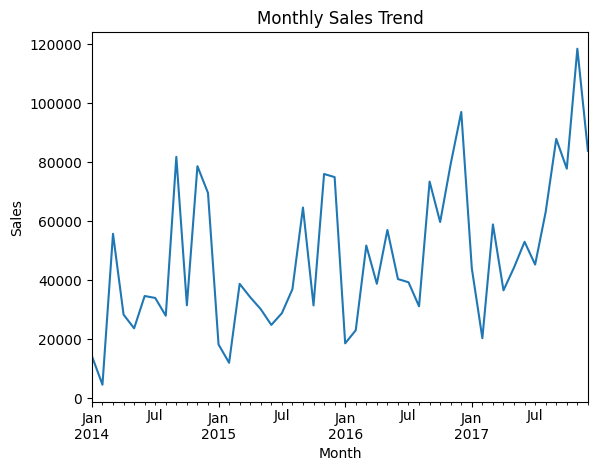

In [11]:
# plot trend 

import matplotlib.pyplot as plt

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## Monthly Profit Trend

profit changes over time (not just sales)

In [12]:
monthly_profit = df.groupby('Month')['Profit'].sum()
monthly_profit

Month
2014-01     2450.1907
2014-02      862.3084
2014-03      498.7299
2014-04     3488.8352
2014-05     2738.7096
2014-06     4976.5244
2014-07     -841.4826
2014-08     5318.1050
2014-09     8328.0994
2014-10     3448.2573
2014-11     9292.1269
2014-12     8983.5699
2015-01    -3281.0070
2015-02     2813.8508
2015-03     9732.0978
2015-04     4187.4962
2015-05     4667.8690
2015-06     3335.5572
2015-07     3288.6483
2015-08     5355.8084
2015-09     8209.1627
2015-10     2817.3660
2015-11    12474.7884
2015-12     8016.9659
2016-01     2824.8233
2016-02     5004.5795
2016-03     3611.9680
2016-04     2977.8149
2016-05     8662.1464
2016-06     4750.3781
2016-07     4432.8779
2016-08     2062.0693
2016-09     9328.6576
2016-10    16243.1425
2016-11     4011.4075
2016-12    17885.3093
2017-01     7140.4391
2017-02     1613.8720
2017-03    14751.8915
2017-04      933.2900
2017-05     6342.5828
2017-06     8223.3357
2017-07     6952.6212
2017-08     9040.9557
2017-09    10991.5556
2017

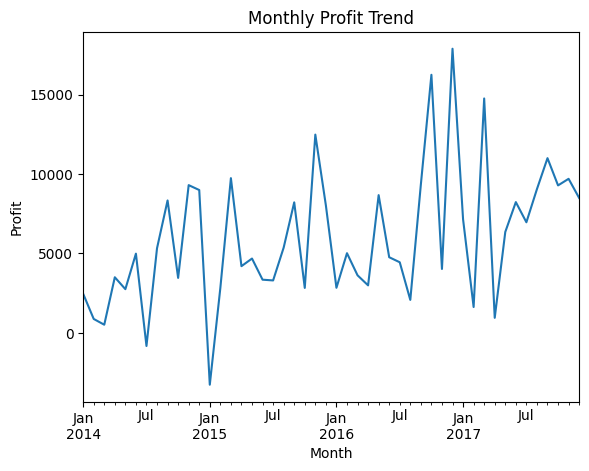

In [13]:
#plot trend 
# whether revenue growth actually translates into profit growth

monthly_profit.plot(kind='line')
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.show()

## Sales vs Profit Trend

revenue vs profit over time

Is the company actually making more money overall, or just selling more but not earning more profit?


In [14]:
# group

monthly = df.groupby('Month')[['Sales', 'Profit']].sum()

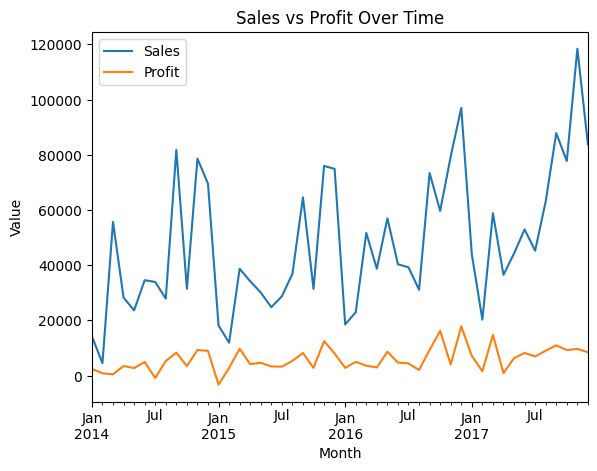

In [15]:
# plot 

import matplotlib.pyplot as plt

monthly.plot(kind='line')
plt.title("Sales vs Profit Over Time")
plt.xlabel("Month")
plt.ylabel("Value")
plt.show()

## Key Insights
* Technology is the most profitable category and drives overall business earnings.
* Furniture generates high sales but very low profit, showing inefficiency.
* Office Supplies provides stable and balanced performance.
* Sales growth does not always translate into profit growth.
* Monthly trends show fluctuations, meaning performance is not consistent across time.


## Conclusion

The business is profitable overall but heavily dependent on Technology. Some categories and time periods show weak profitability, meaning growth is not fully efficient and needs better cost and pricing control.